<a href="https://colab.research.google.com/github/GNMoyano/InteligenciaArtificial/blob/main/Limpieza_Datos_Cr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Exploratorio

In [24]:
# Importaciones necesrias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [19]:
#Leemos el conjuntos de datos
df = pd.read_csv('data_2.csv', delimiter=';')

In [20]:
# Visualizamos los primeros registros del conjunto de datos
df.head()

,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,protocol_ICMP,protocol_TCP,protocol_UDP,attack
0,2.0,0.250000,0.06849661286745308,0.438165,0.0,0.655587,0.2,0.0,0.0,1.0,0.0,1.0
1,3.0,0.166667,0.21662306124686573,0.334152,0.0,0.324443,0.0,0.0,0.0,1.0,0.0,0.0
2,4.0,0.166667,0.010367924783900546,0.462735,0.0,0.799160,0.4,0.0,0.0,1.0,0.0,1.0
3,1.0,0.250000,0.08355463717816522,0.606061,0.0,0.131015,0.0,0.0,0.0,0.0,1.0,1.0
4,3.0,0.333333,0.07399845125501123,0.318591,1.0,0.056820,0.2,0.0,0.0,1.0,0.0,0.0


No hay columna attack? eso está bien?

Realizamos un análisis inicial viendo:

*   Cantidad de registros
*   Variables
*   tipos
*   etc


In [26]:
# Vemos información sobre el dataset
# Para transformar 'duration' en float64
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9821 entries, 0 to 9820
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   browser_type         9537 non-null   float64
 1   login_attempts       9537 non-null   float64
 2   duration             9530 non-null   float64
 3   packet_size          9537 non-null   float64
 4   encryption_used      9537 non-null   float64
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   float64
 7   unusual_time_access  9537 non-null   float64
 8   protocol_ICMP        9537 non-null   float64
 9   protocol_TCP         9537 non-null   float64
 10  protocol_UDP         9537 non-null   float64
 11  attack               9537 non-null   float64
dtypes: float64(12)
memory usage: 920.8 KB


In [27]:
# Forma del Dataset
df.shape

(9821, 12)

El dataset tiene 10546 registros con 12 columnas

In [28]:
# Vemos los nombres de las distintas columnas
df.columns

Index(['browser_type', 'login_attempts', 'duration', 'packet_size',
       'encryption_used', 'ip_reputation_score', 'failed_logins',
       'unusual_time_access', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP',
       'attack'],
      dtype='object')

In [29]:
df.dtypes

browser_type           float64
login_attempts         float64
duration               float64
packet_size            float64
encryption_used        float64
ip_reputation_score    float64
failed_logins          float64
unusual_time_access    float64
protocol_ICMP          float64
protocol_TCP           float64
protocol_UDP           float64
attack                 float64
dtype: object

In [33]:
# Vemos medidas de tendencia central y dispersión de las variables numericas
df.describe(include=np.number)

,Unnamed: 0,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,protocol_ICMP,protocol_TCP,protocol_UDP
count,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000,10546.000000
mean,5272.500000,3.121089,0.257531,0.110892,0.357163,0.624028,0.360143,0.311189,0.150104,0.053196,0.693533,0.253271
std,3044.512304,1.165425,0.165626,0.110254,0.161998,0.484396,0.194753,0.211598,0.357191,0.224434,0.461048,0.434906
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2636.250000,2.000000,0.166667,0.032388,0.246519,0.000000,0.207276,0.200000,0.000000,0.000000,0.000000,0.000000
50%,5272.500000,4.000000,0.250000,0.077595,0.356265,1.000000,0.340931,0.200000,0.000000,0.000000,1.000000,0.000000
75%,7908.750000,4.000000,0.333333,0.153914,0.466830,1.000000,0.493653,0.400000,0.000000,0.000000,1.000000,1.000000
max,10545.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
#quiero que intente hacer un describe de los tipos 'object', pero si da error que muestre un mensaje de "no se pudo hacer describe de los tipos 'object'
# Intentamos hacer un describe de los tipos 'object'
try:
    df.describe(include='object')
except Exception as e:
    print("No se pudo hacer describe de los tipos 'object':", e)


No se pudo hacer describe de los tipos 'object': No objects to concatenate


In [30]:
df.isnull().sum()

browser_type           284
login_attempts         284
duration               291
packet_size            284
encryption_used        284
ip_reputation_score    284
failed_logins          284
unusual_time_access    284
protocol_ICMP          284
protocol_TCP           284
protocol_UDP           284
attack                 284
dtype: int64

## Gráficos

Vemos algunos gráficos de las variables

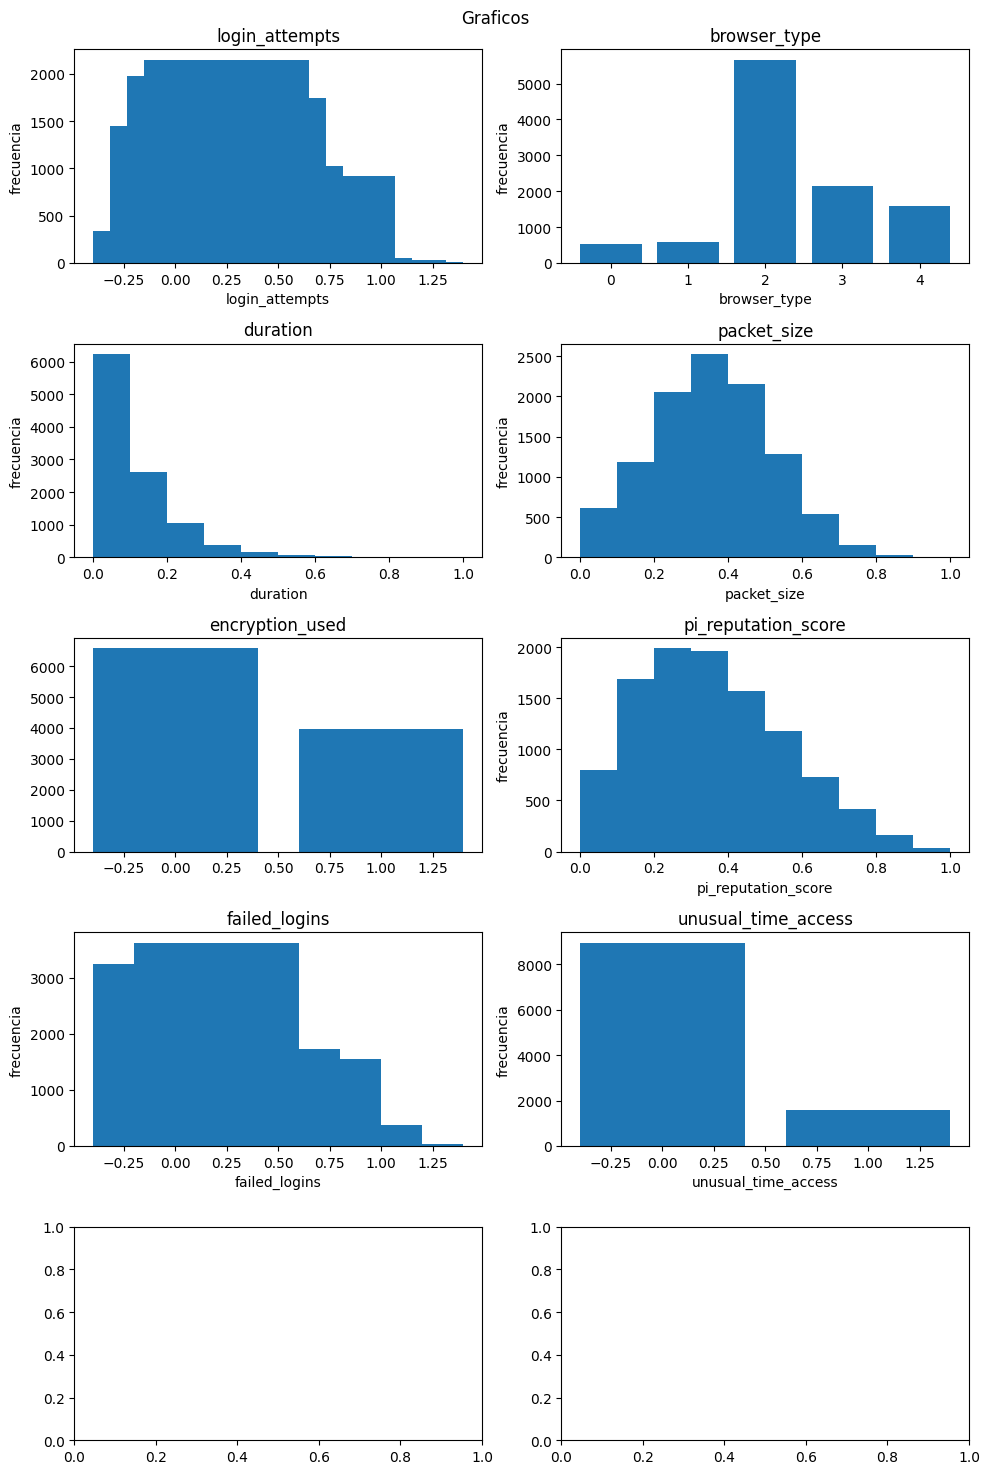

In [36]:
fig, ax = plt.subplots(5, 2)
fig.set_figheight(15)
fig.set_figwidth(10)
fig.suptitle('Graficos')

# Columna 'login_attemps'
ax[0,0].bar(df.login_attempts.unique(), df.login_attempts.value_counts())
ax[0,0].set_title('login_attempts')
ax[0,0].set_xlabel('login_attempts')
ax[0,0].set_ylabel('frecuencia')

# Columna 'browser_type'
ax[0,1].bar(df.browser_type.unique(), df.browser_type.value_counts())
ax[0,1].set_title('browser_type')
ax[0,1].set_xlabel('browser_type')
ax[0,1].set_ylabel('frecuencia')

# Columna 'duration' boxplot
ax[1,0].hist(df.duration)
ax[1,0].set_title('duration')
ax[1,0].set_xlabel('duration')
ax[1,0].set_ylabel('frecuencia')

# Columna 'packet_size'
ax[1,1].hist(df.packet_size)
ax[1,1].set_title('packet_size')
ax[1,1].set_xlabel('packet_size')
ax[1,1].set_ylabel('frecuencia')

# Columna 'encryption_used' bar
ax[2,0].bar(df.encryption_used.unique(), df.encryption_used.value_counts())
ax[2,0].set_title('encryption_used')


# Columna 'pi_reputation_score'
ax[2,1].hist(df.ip_reputation_score)
ax[2,1].set_title('pi_reputation_score')
ax[2,1].set_xlabel('pi_reputation_score')
ax[2,1].set_ylabel('frecuencia')

# Columna 'failed_logins'
ax[3,0].bar(df.failed_logins.unique(), df.failed_logins.value_counts())
ax[3,0].set_title('failed_logins')
ax[3,0].set_xlabel('failed_logins')
ax[3,0].set_ylabel('frecuencia')

# Columna 'unusual_time_access'
ax[3,1].bar(df.unusual_time_access.unique(), df.unusual_time_access.value_counts())
ax[3,1].set_title('unusual_time_access')
ax[3,1].set_xlabel('unusual_time_access')
ax[3,1].set_ylabel('frecuencia')

''' No hay columna attack?
# Columna 'attack'
ax[4,0].pie(df.attack.value_counts(), labels=df.attack.unique(), autopct='%1.1f%%')
ax[4,0].set_title('attack')
ax[4,0].set_xlabel('attack')
ax[4,0].set_ylabel('frecuencia')
'''

plt.tight_layout()
plt.show()


# Procesamiento de Datos

## Analisis de las variables


Eliminamos la columna de ID ya que no aporta información relevante al modelo

In [37]:
# eliminar la columna sin nombre
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

#df = df.drop('ID', axis=1)

In [38]:
df.head()

,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,protocol_ICMP,protocol_TCP,protocol_UDP
0,2,0.250000,0.068497,0.438165,0,0.655587,0.2,0.0,0,1,0
1,3,0.166667,0.216623,0.334152,0,0.324443,0.0,0.0,0,1,0
2,4,0.166667,0.010368,0.462735,0,0.799160,0.4,0.0,0,1,0
3,1,0.250000,0.083555,0.606061,0,0.131015,0.0,0.0,0,0,1
4,3,0.333333,0.073998,0.318591,1,0.056820,0.2,0.0,0,1,0


## Valores atípicos

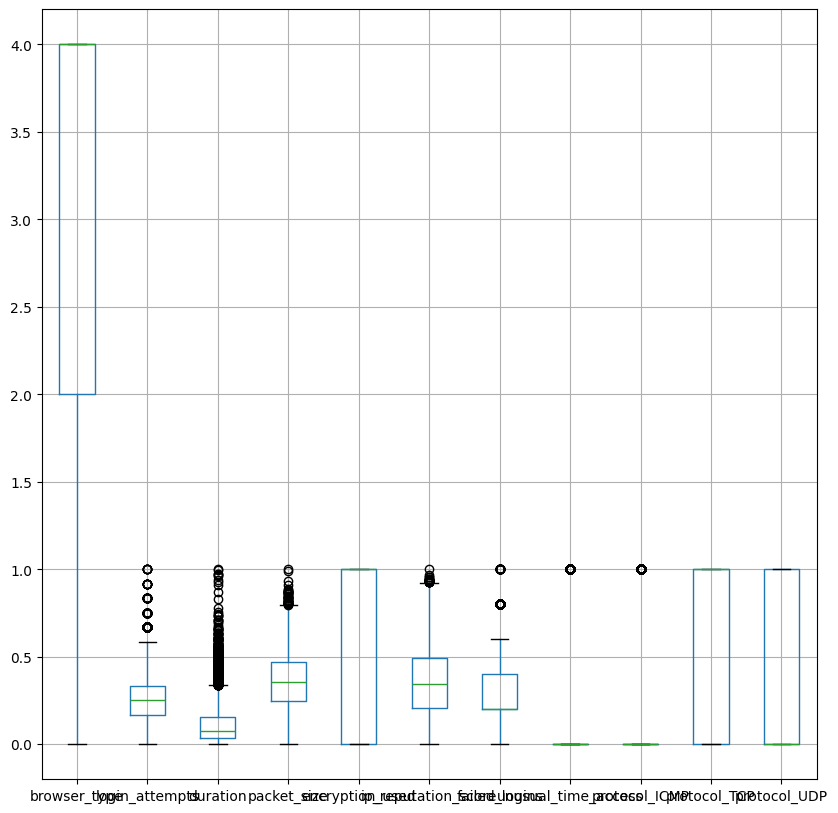

In [39]:
# Boxplot para visualizar valores atípicos
df.boxplot(figsize=(10,10))
plt.show()

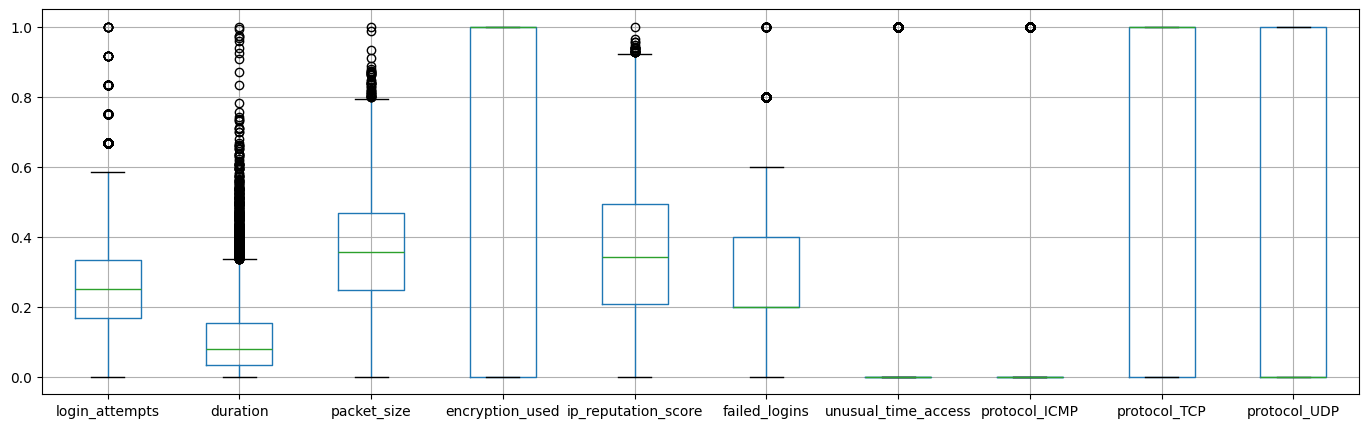

In [40]:
# Mostrar el Boxplot sin la columan browser_type y sin modificar el df original
df_copy = df.copy()
df_copy.drop(columns=['browser_type']).boxplot(figsize=(17,5))
plt.show()



Se ven varios valores atipicos en las variables númericas, pero ya están normalizadas

In [42]:
df

,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,protocol_ICMP,protocol_TCP,protocol_UDP
0,2,0.250000,0.068497,0.438165,0,0.655587,0.2,0.0,0,1,0
1,3,0.166667,0.216623,0.334152,0,0.324443,0.0,0.0,0,1,0
2,4,0.166667,0.010368,0.462735,0,0.799160,0.4,0.0,0,1,0
3,1,0.250000,0.083555,0.606061,0,0.131015,0.0,0.0,0,0,1
4,3,0.333333,0.073998,0.318591,1,0.056820,0.2,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
10541,0,0.166667,0.025119,0.308763,1,0.719605,0.4,0.0,0,1,0
10542,4,0.583333,0.047502,0.524980,1,0.193946,0.2,1.0,0,1,0
10543,4,0.333333,0.252314,0.340704,1,0.705939,0.2,0.0,0,0,1
10544,3,0.500000,0.005754,0.208845,1,0.296032,0.2,0.0,0,1,0


## Correlación entre variables

In [43]:
# Calculamos todos los coeficientes de correlacion
corr= df.corr(numeric_only=True)
corr

,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,protocol_ICMP,protocol_TCP,protocol_UDP
browser_type,1.000000,0.003382,-0.003946,-0.010825,-0.008548,-0.007944,0.002696,0.007362,0.020691,-0.012115,0.002165
login_attempts,0.003382,1.000000,0.008511,0.001266,-0.003812,-0.010577,-0.027863,0.009077,-0.008652,-0.025348,0.031337
duration,-0.003946,0.008511,1.000000,0.024525,0.009717,-0.009443,0.014331,0.013484,-0.003314,0.006378,-0.005051
packet_size,-0.010825,0.001266,0.024525,1.000000,-0.018743,0.003111,-0.020227,0.000232,0.007161,-0.015418,0.012650
encryption_used,-0.008548,-0.003812,0.009717,-0.018743,1.000000,0.011612,0.003946,0.002830,0.000803,0.003337,-0.003952
ip_reputation_score,-0.007944,-0.010577,-0.009443,0.003111,0.011612,1.000000,0.003340,-0.002712,-0.014409,-0.021945,0.030700
failed_logins,0.002696,-0.027863,0.014331,-0.020227,0.003946,0.003340,1.000000,0.003749,0.005238,0.012018,-0.015443
unusual_time_access,0.007362,0.009077,0.013484,0.000232,0.002830,-0.002712,0.003749,1.000000,0.010400,-0.007407,0.002485
protocol_ICMP,0.020691,-0.008652,-0.003314,0.007161,0.000803,-0.014409,0.005238,0.010400,1.000000,-0.356574,-0.138044
protocol_TCP,-0.012115,-0.025348,0.006378,-0.015418,0.003337,-0.021945,0.012018,-0.007407,-0.356574,1.000000,-0.876100


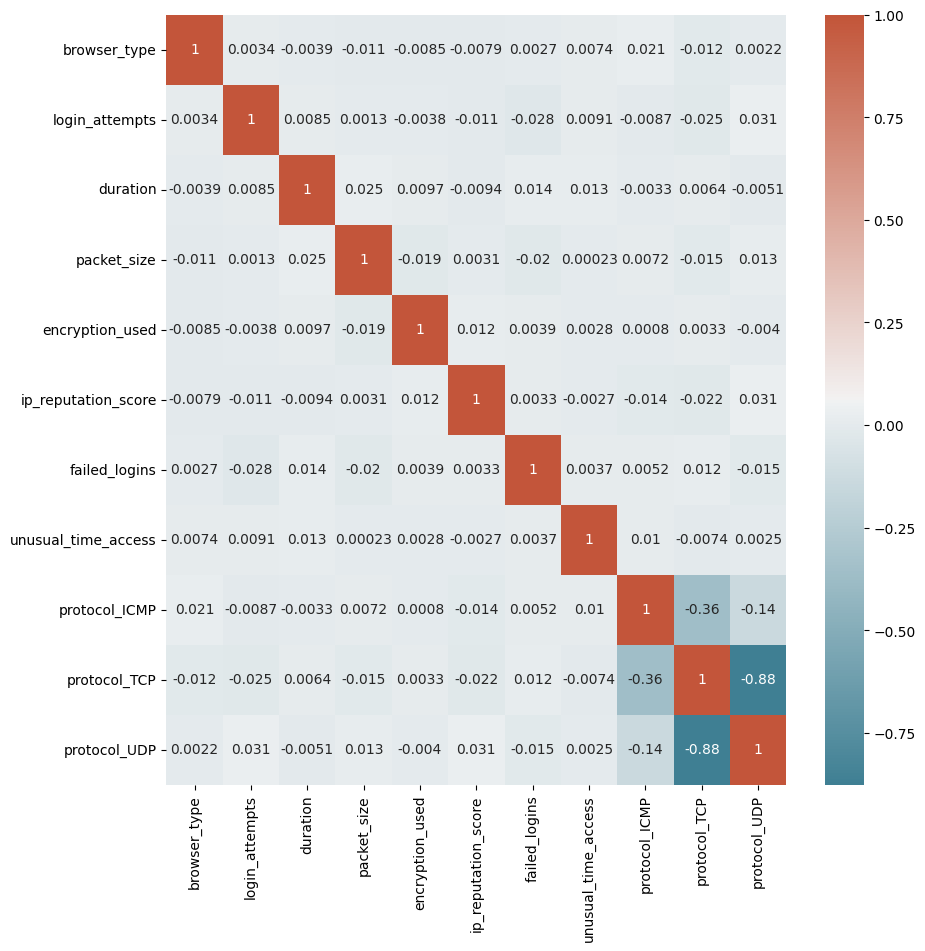

In [44]:
# Visualizamos la matriz de correlacion
plt.figure(figsize=(10,10))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.show()

Tienen una correlacion muy baja todas las varriables, por lo que no hay necesidad de eliminar variables

## Balance del conjunto de datos

No lo podemos hacer sin decidir cómo resolvemos la columna "attack".
Mi recomendación? Copiamos las del df original y las pegamos en este. Borramos las que tienen NaN y gg ez tutorial

In [45]:
# Visualizar el balance del dataset
sns.countplot(x='attack', data=df)
plt.show()

ValueError: Could not interpret value `attack` for `x`. An entry with this name does not appear in `data`.

La variable attack esta desbalanceada por lo que optamos por hacer un UnderSample para disminuir la cantidad de muestras de la clase mayoritaria

In [ ]:
# Seleccionar las columnas del dataset que corresponden a
# las entradas del modelo y la salida esperada
X = df.drop('attack', axis=1)
y = df['attack']

In [ ]:
# Importar el paquete imblearn para underSampling
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Generar un nuevos conjunto de datos balanceado por Under-Sampling
undersampling = RandomUnderSampler(random_state=42)
X_under, y_under = undersampling.fit_resample(X, y)

<Axes: xlabel='attack', ylabel='count'>

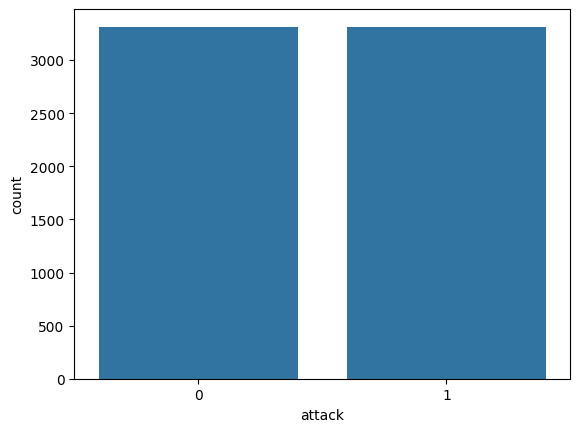

In [ ]:
# Visualizamos el balance del dataset generado
sns.countplot(x=y_under)